# Tarea 4: Modelo


In [1]:
pip install mlflow

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.0.1 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
pip install scikit-learn

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.0.1 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import warnings
import pickle
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (classification_report, confusion_matrix,
                             f1_score, accuracy_score,
                             precision_score, recall_score)

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, BatchNormalization, Input
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.callbacks import EarlyStopping

import mlflow
import mlflow.tensorflow

## Datos df_modelo

In [3]:
df_modelo_preg1 = pd.read_csv('df_modelo_preg1.csv')

print(df_modelo_preg1.head())


   COLE_AREA_UBICACION_NUM  COLE_BILINGUE_NUM  COLE_GENERO_FEMENINO  \
0                        0                  0                     0   
1                        0                  0                     0   
2                        0                  0                     0   
3                        1                  0                     0   
4                        0                  0                     0   

   COLE_GENERO_MASCULINO  COLE_GENERO_MIXTO  COLE_JORNADA_COMPLETA  \
0                      0                  1                      0   
1                      0                  1                      0   
2                      0                  1                      1   
3                      0                  1                      0   
4                      0                  1                      0   

   COLE_JORNADA_MAÑANA  COLE_JORNADA_NOCHE  COLE_JORNADA_SABATINA  \
0                    0                   0                      0   
1             

## Interacciones Relevantes

4 variables de interracción

- **ES_PRIVILEGIADO**: combina bilingüismo y ubicación urbana. El EDA mostró que los colegios 
bilingües tienen los puntajes más altos, y la mayoría se concentra en zonas urbanas con mayor 
acceso a recursos.

- **JORNADA_EXTENDIDA**: identifica colegios con jornada completa o única, que implican mayor 
tiempo de exposición académica. El EDA confirmó que estas jornadas están asociadas a mejores 
desempeños frente a jornadas de mañana, tarde o noche.

- **COLEGIO_NO_MIXTO**: marca colegios masculinos o femeninos. El análisis exploratorio evidenció 
que estos colegios tienden a obtener mejores puntajes en matemáticas que los mixtos, que 
representan el 98.5% de los datos.

- **COLEGIO_TOP**: intersección de ES_PRIVILEGIADO y JORNADA_EXTENDIDA. Captura el perfil de 
colegio con las condiciones más favorables para el alto desempeño según el EDA.

In [5]:

#colegio bilingüe + urbano --- mayor acceso a recursos educativos
df_modelo_preg1['ES_PRIVILEGIADO'] = (
    (df_modelo_preg1['COLE_BILINGUE_NUM'] == 1) &
    (df_modelo_preg1['COLE_AREA_UBICACION_NUM'] == 0)
).astype(int)

#jornada completa o única --- mayor tiempo de estudio
df_modelo_preg1['JORNADA_EXTENDIDA'] = (
    (df_modelo_preg1['COLE_JORNADA_COMPLETA'] == 1) |
    (df_modelo_preg1['COLE_JORNADA_UNICA'] == 1)
).astype(int)

#colegio masculino o femenino --- EDA mostró mejor desempeño vs mixtos
df_modelo_preg1['COLEGIO_NO_MIXTO'] = (
    (df_modelo_preg1['COLE_GENERO_FEMENINO'] == 1) |
    (df_modelo_preg1['COLE_GENERO_MASCULINO'] == 1)
).astype(int)

#combinación del mejor perfil: bilingüe + urbano + jornada extendida
df_modelo_preg1['COLEGIO_TOP'] = (
    (df_modelo_preg1['ES_PRIVILEGIADO'] == 1) &
    (df_modelo_preg1['JORNADA_EXTENDIDA'] == 1)
).astype(int)

#distribucion
nuevas = ['ES_PRIVILEGIADO', 'JORNADA_EXTENDIDA', 'COLEGIO_NO_MIXTO', 'COLEGIO_TOP']
print("Distribución de features de interacción:")
for col in nuevas:
    n1 = df_modelo_preg1[col].sum()
    pct = df_modelo_preg1[col].mean() * 100
    print(f"  {col:25s}: {n1:>7,}  ({pct:.1f}%)")

print(f"\nShape final: {df_modelo_preg1.shape}")

Distribución de features de interacción:
  ES_PRIVILEGIADO          :     967  (0.2%)
  JORNADA_EXTENDIDA        : 134,946  (34.3%)
  COLEGIO_NO_MIXTO         :   5,887  (1.5%)
  COLEGIO_TOP              :     500  (0.1%)

Shape final: (393265, 17)


## Nuevo dataframe y primeros pasos del modelo

In [6]:
#objetivo: Alto (1) vs No-Alto (0)
print(df_modelo_preg1['ALTO_RENDIMIENTO'].value_counts().rename({0: 'No-Alto', 1: 'Alto'}))
print("Únicos:", df_modelo_preg1['ALTO_RENDIMIENTO'].unique())

#caracteristicas finales del modelo
CARACTERISTICAS = [
    'COLE_AREA_UBICACION_NUM',
    'COLE_BILINGUE_NUM',
    *[col for col in df_modelo_preg1.columns if 'COLE_GENERO_' in col],
    *[col for col in df_modelo_preg1.columns if 'COLE_JORNADA_' in col],
    'ES_PRIVILEGIADO',
    'JORNADA_EXTENDIDA',
    'COLEGIO_NO_MIXTO',
    'COLEGIO_TOP',
]

TARGET = 'ALTO_RENDIMIENTO'

#validar
CARACTERISTICAS = [c for c in CARACTERISTICAS if c in df_modelo_preg1.columns]
N_FEATURES = len(CARACTERISTICAS)

#datos
X = df_modelo_preg1[CARACTERISTICAS].values.astype(np.float32)
y = df_modelo_preg1[TARGET].values  # 0 = No-Alto, 1 = Alto

#print bonito
print("Clases únicas:", np.unique(y))  # debe ser [0 1]
print(f"Número de features: {N_FEATURES}")
print("\nDistribución:")
print(f"  No-Alto (0): {(y == 0).sum():,}  ({(y == 0).mean()*100:.1f}%)")
print(f"  Alto    (1): {(y == 1).sum():,}  ({(y == 1).mean()*100:.1f}%)")

ALTO_RENDIMIENTO
No-Alto    252664
Alto       140601
Name: count, dtype: int64
Únicos: [0 1]
Clases únicas: [0 1]
Número de features: 15

Distribución:
  No-Alto (0): 252,664  (64.2%)
  Alto    (1): 140,601  (35.8%)


## Split

In [7]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import joblib
import numpy as np

#split 70% train, val=15%, test=15%
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.5, random_state=42, stratify=y_temp
)

#escalar
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train).astype(np.float32)
X_val_scaled   = scaler.transform(X_val).astype(np.float32)
X_test_scaled  = scaler.transform(X_test).astype(np.float32)

joblib.dump(scaler, "scaler_preg1.pkl")

#print
print(f"Train: {X_train_scaled.shape}")
print(f"Val:   {X_val_scaled.shape}")
print(f"Test:  {X_test_scaled.shape}")

print("\nDistribución train:")
print(f"  No-Alto (0): {(y_train==0).sum():,}  ({(y_train==0).mean()*100:.1f}%)")
print(f"  Alto    (1): {(y_train==1).sum():,}  ({(y_train==1).mean()*100:.1f}%)")

print("\nDistribución test:")
print(f"  No-Alto (0): {(y_test==0).sum():,}  ({(y_test==0).mean()*100:.1f}%)")
print(f"  Alto    (1): {(y_test==1).sum():,}  ({(y_test==1).mean()*100:.1f}%)")

Train: (275285, 15)
Val:   (58990, 15)
Test:  (58990, 15)

Distribución train:
  No-Alto (0): 176,864  (64.2%)
  Alto    (1): 98,421  (35.8%)

Distribución test:
  No-Alto (0): 37,900  (64.2%)
  Alto    (1): 21,090  (35.8%)


## visualizaciones

In [8]:
PALETTE = ['#F5A623', '#F8C15C', '#4ABFBF', '#6FD4D4', '#2E86AB', '#1B5E84']

COLOR_BAJO = '#F5A623'   
COLOR_ALTO = '#2E86AB'   
COLOR_MAIN = '#4ABFBF'   
COLOR_LIGHT = '#6FD4D4'  

COLOR_TRAIN = '#2E86AB'   
COLOR_VAL   = '#F5A623'   
COLOR_CM    = sns.light_palette('#4ABFBF', as_cmap=True)  #matriz confusión

from sklearn.metrics import (
    accuracy_score, f1_score, precision_score, recall_score,
    classification_report, confusion_matrix,
    roc_curve, auc
)

def evaluar_modelo(nombre, y_test, y_pred, y_prob=None, history=None, guardar=True):

    CLASES = ['No-Alto', 'Alto'] 

    print(classification_report(y_test, y_pred, target_names=CLASES))

    acc    = accuracy_score(y_test, y_pred)
    f1_mac = f1_score(y_test, y_pred, average='macro')
    f1_per = f1_score(y_test, y_pred, average=None)
    prec   = precision_score(y_test, y_pred, average='macro')
    rec    = recall_score(y_test, y_pred, average='macro')

    print(f"\n{'='*55}")
    print(f" Modelo: {nombre}")
    print(f"{'='*55}")
    print(f"  Accuracy       : {acc:.4f}")
    print(f"  F1 Macro       : {f1_mac:.4f}")
    print(f"  Precision Macro: {prec:.4f}")
    print(f"  Recall Macro   : {rec:.4f}")
    print(f"  F1 No-Alto     : {f1_per[0]:.4f}")
    print(f"  F1 Alto        : {f1_per[1]:.4f}")
    print()
    print(classification_report(y_test, y_pred, target_names=CLASES))

    nombre_archivo = nombre.replace(' ', '_')

    #ROC
    tiene_history = history is not None
    tiene_roc = y_prob is not None

    ncols = 1
    if tiene_history:
        ncols += 2
    if tiene_roc:
        ncols += 1

    fig, axes = plt.subplots(1, ncols, figsize=(6*ncols, 5))

    if ncols == 1:
        axes = [axes]

    i = 0

    #Matriz de confusion
    COLOR_CM = sns.light_palette('#4ABFBF', as_cmap=True)
    
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap=COLOR_CM,
                xticklabels=CLASES, yticklabels=CLASES, ax=axes[i],
                linewidths=0.5, linecolor='white')

    axes[i].set_title(f'Matriz de Confusión\n{nombre}', fontsize=13, fontweight='bold')
    axes[i].set_ylabel('Real')
    axes[i].set_xlabel('Predicho')
    i += 1

    # curva ROC

    
    if tiene_roc:
        fpr, tpr, _ = roc_curve(y_test, y_prob)
        roc_auc = auc(fpr, tpr)

        axes[i].plot(fpr, tpr, color=COLOR_TRAIN, linewidth=2,
                     label=f'AUC = {roc_auc:.3f}')
        axes[i].plot([0, 1], [0, 1], linestyle='--', color='gray')

        axes[i].set_title('Curva ROC', fontsize=13, fontweight='bold')
        axes[i].set_xlabel('False Positive Rate')
        axes[i].set_ylabel('True Positive Rate')
        axes[i].legend()
        axes[i].grid(alpha=0.3)
        axes[i].spines[['top', 'right']].set_visible(False)

        i += 1
    else:
        roc_auc = None

    # historial de perdida
    if tiene_history:
        epochs_range = range(1, len(history.history['loss']) + 1)

        axes[i].plot(epochs_range, history.history['loss'],
                     label='Train', color=COLOR_TRAIN, linewidth=2)
        axes[i].plot(epochs_range, history.history['val_loss'],
                     label='Val', color=COLOR_VAL, linestyle='--', linewidth=2)

        axes[i].set_title('Historial de Pérdida', fontsize=13, fontweight='bold')
        axes[i].set_xlabel('Época')
        axes[i].set_ylabel('Loss')
        axes[i].legend()
        axes[i].grid(alpha=0.3, linestyle='--')
        axes[i].spines[['top', 'right']].set_visible(False)

        i += 1

        #accuracy historial
        axes[i].plot(epochs_range, history.history['accuracy'],
                     label='Train', color=COLOR_TRAIN, linewidth=2)
        axes[i].plot(epochs_range, history.history['val_accuracy'],
                     label='Val', color=COLOR_VAL, linestyle='--', linewidth=2)

        axes[i].set_title('Historial de Accuracy', fontsize=13, fontweight='bold')
        axes[i].set_xlabel('Época')
        axes[i].set_ylabel('Accuracy')
        axes[i].legend()
        axes[i].grid(alpha=0.3, linestyle='--')
        axes[i].spines[['top', 'right']].set_visible(False)

    plt.suptitle(f'Evaluación — {nombre}', fontsize=15, fontweight='bold', y=1.02)
    plt.tight_layout()

    if guardar:
        ruta = f'grafica_{nombre_archivo}.png'
        plt.savefig(ruta, dpi=150, bbox_inches='tight')
        print(f"  ✓ Gráfica guardada: {ruta}")

    plt.show()

    return {
        'accuracy':    round(acc, 4),
        'f1_macro':    round(f1_mac, 4),
        'precision':   round(prec, 4),
        'recall':      round(rec, 4),
        'f1_no_alto':  round(f1_per[0], 4),
        'f1_alto':     round(f1_per[1], 4),
        'roc_auc':     round(roc_auc, 4) if roc_auc is not None else None
    }

## Parametros

In [9]:
print("=" * 55)
print(f" ARQUITECTURA MLP1 BASE: {N_FEATURES} → 64 → 32 → 1")
print("=" * 55)
c1_base = N_FEATURES * 64 + 64
c2_base = 64 * 32 + 32
cs_base = 32 * 1 + 1              #salida binaria
total_base = c1_base + c2_base + cs_base
print(f"  Capa oculta 1  ({N_FEATURES}→64)  : {c1_base:>6,}  parámetros")
print(f"  Capa oculta 2  (64→32)   : {c2_base:>6,}  parámetros")
print(f"  Capa de salida (32→1)    : {cs_base:>6,}  parámetros")
print(f"  {'─'*38}")
print(f"  Total                    : {total_base:>6,}  parámetros")

print()
print("=" * 55)
print(f" ARQUITECTURA MLP2 OPTIMIZADA: {N_FEATURES} → 128 → 64 → 32 → 1")
print("=" * 55)
c1_opt = N_FEATURES * 128 + 128
c2_opt = 128 * 64 + 64
c3_opt = 64 * 32 + 32
cs_opt = 32 * 1 + 1               #salida binaria
total_opt = c1_opt + c2_opt + c3_opt + cs_opt
print(f"  Capa oculta 1  ({N_FEATURES}→128) : {c1_opt:>6,}  parámetros")
print(f"  Capa oculta 2  (128→64)  : {c2_opt:>6,}  parámetros")
print(f"  Capa oculta 3  (64→32)   : {c3_opt:>6,}  parámetros")
print(f"  Capa de salida (32→1)    : {cs_opt:>6,}  parámetros")
print(f"  {'─'*38}")
print(f"  Total                    : {total_opt:>6,}  parámetros")
print(f"\n  Nota: BatchNormalization agrega 4×neuronas parámetros")
print(f"  adicionales (verificar con model.summary() más abajo)")

 ARQUITECTURA MLP1 BASE: 15 → 64 → 32 → 1
  Capa oculta 1  (15→64)  :  1,024  parámetros
  Capa oculta 2  (64→32)   :  2,080  parámetros
  Capa de salida (32→1)    :     33  parámetros
  ──────────────────────────────────────
  Total                    :  3,137  parámetros

 ARQUITECTURA MLP2 OPTIMIZADA: 15 → 128 → 64 → 32 → 1
  Capa oculta 1  (15→128) :  2,048  parámetros
  Capa oculta 2  (128→64)  :  8,256  parámetros
  Capa oculta 3  (64→32)   :  2,080  parámetros
  Capa de salida (32→1)    :     33  parámetros
  ──────────────────────────────────────
  Total                    : 12,417  parámetros

  Nota: BatchNormalization agrega 4×neuronas parámetros
  adicionales (verificar con model.summary() más abajo)


## Experimentos MLFlow

              precision    recall  f1-score   support

     No-Alto       0.66      0.95      0.78     37900
        Alto       0.62      0.13      0.22     21090

    accuracy                           0.66     58990
   macro avg       0.64      0.54      0.50     58990
weighted avg       0.65      0.66      0.58     58990


 Modelo: exploracion_n32-16
  Accuracy       : 0.6614
  F1 Macro       : 0.5025
  Precision Macro: 0.6434
  Recall Macro   : 0.5445
  F1 No-Alto     : 0.7836
  F1 Alto        : 0.2213

              precision    recall  f1-score   support

     No-Alto       0.66      0.95      0.78     37900
        Alto       0.62      0.13      0.22     21090

    accuracy                           0.66     58990
   macro avg       0.64      0.54      0.50     58990
weighted avg       0.65      0.66      0.58     58990

  ✓ Gráfica guardada: grafica_exploracion_n32-16.png


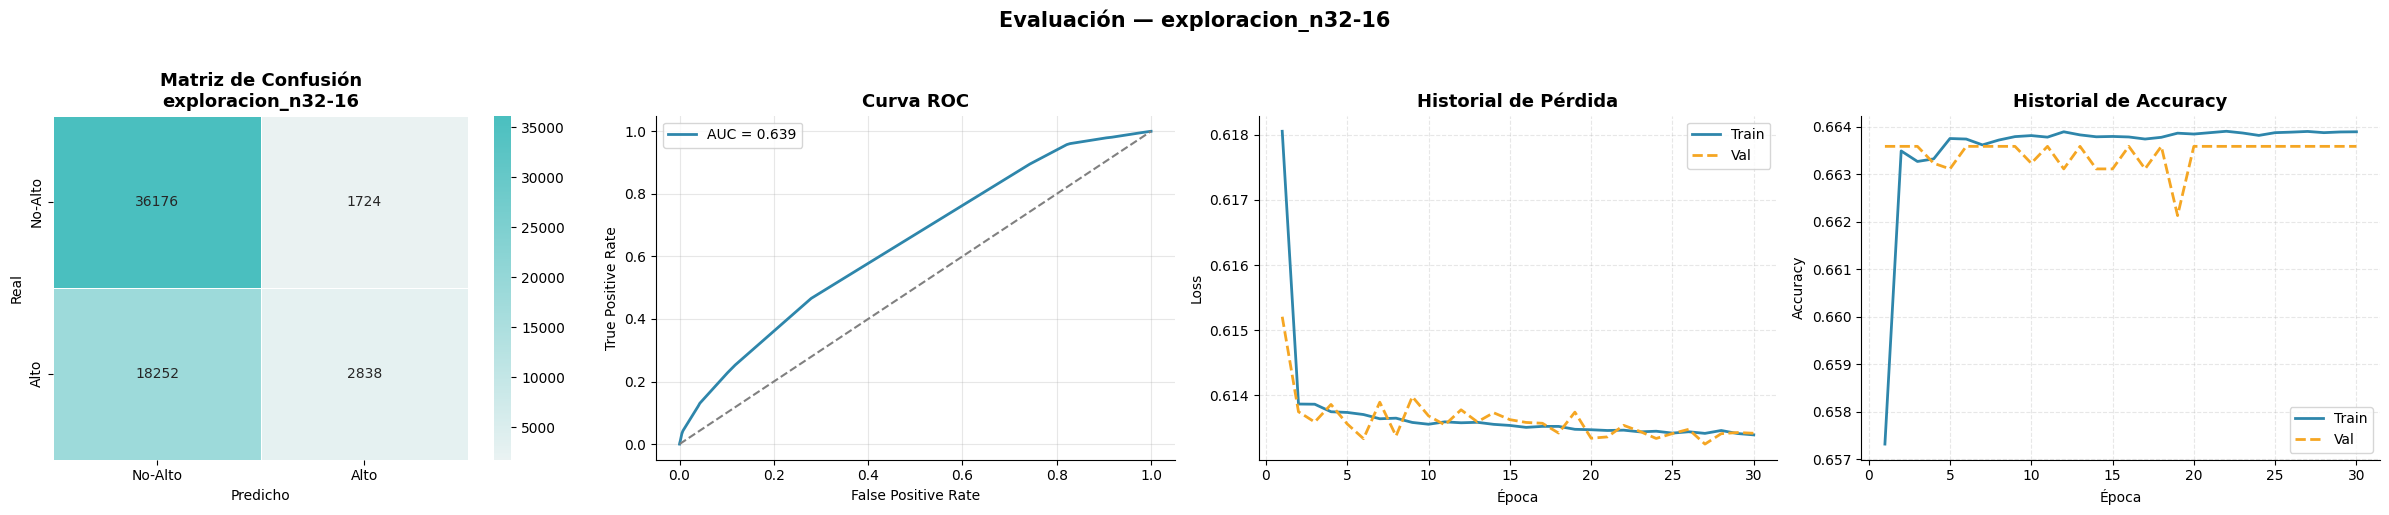

exploracion_n32-16        → F1: 0.2213 | AUC: 0.6388
🏃 View run exploracion_n32-16 at: http://localhost:5000/#/experiments/1/runs/826f0ad868494574ba830ee2b140570e
🧪 View experiment at: http://localhost:5000/#/experiments/1
              precision    recall  f1-score   support

     No-Alto       0.66      0.96      0.78     37900
        Alto       0.63      0.13      0.22     21090

    accuracy                           0.66     58990
   macro avg       0.65      0.54      0.50     58990
weighted avg       0.65      0.66      0.58     58990


 Modelo: exploracion_n64-32
  Accuracy       : 0.6615
  F1 Macro       : 0.5001
  Precision Macro: 0.6462
  Recall Macro   : 0.5437
  F1 No-Alto     : 0.7842
  F1 Alto        : 0.2160

              precision    recall  f1-score   support

     No-Alto       0.66      0.96      0.78     37900
        Alto       0.63      0.13      0.22     21090

    accuracy                           0.66     58990
   macro avg       0.65      0.54      0.50   

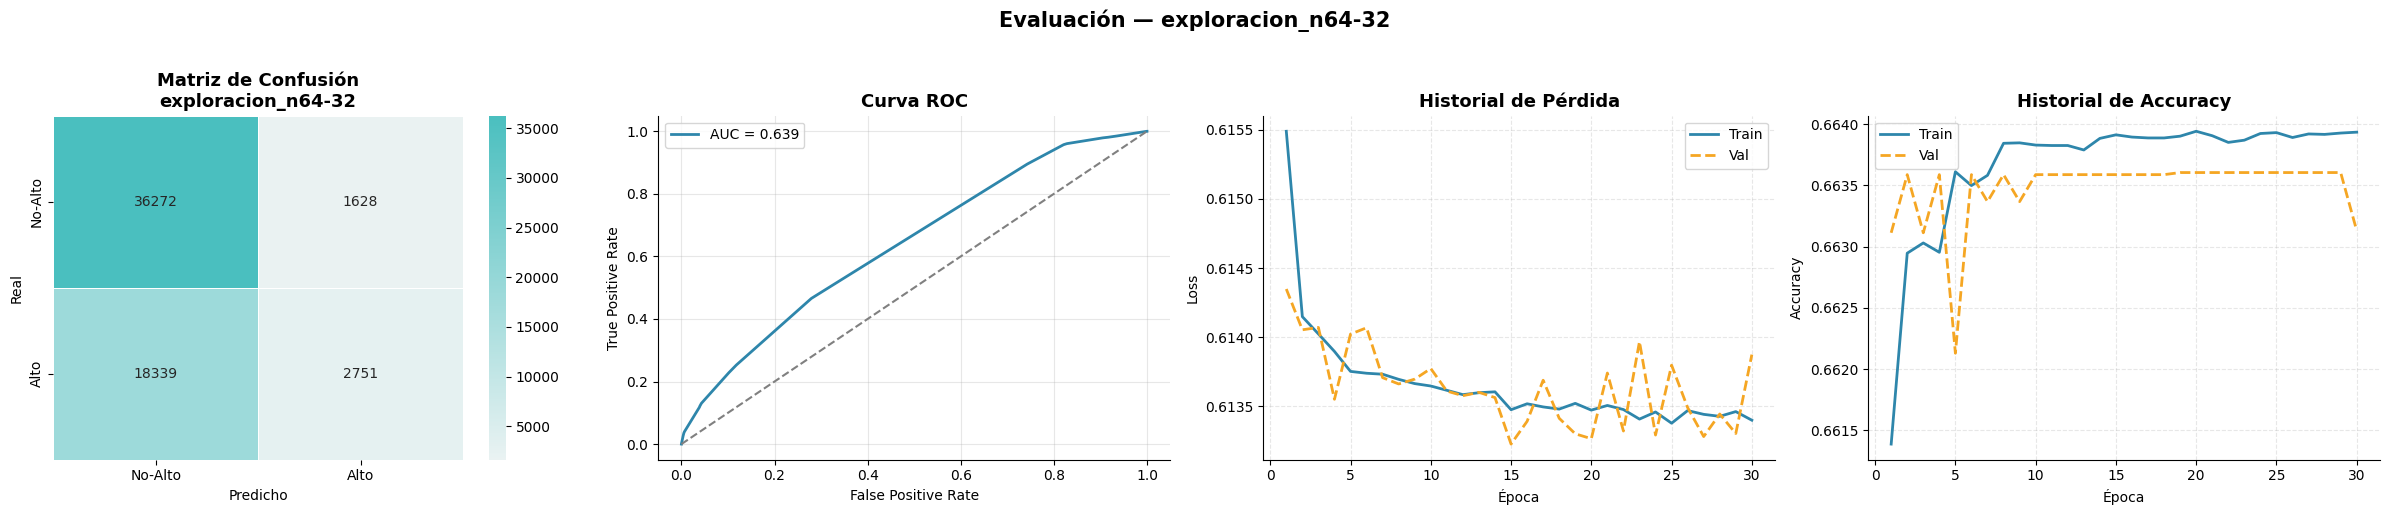

exploracion_n64-32        → F1: 0.2160 | AUC: 0.6388
🏃 View run exploracion_n64-32 at: http://localhost:5000/#/experiments/1/runs/83ba862759584dad97079ce4a5c624a8
🧪 View experiment at: http://localhost:5000/#/experiments/1
              precision    recall  f1-score   support

     No-Alto       0.66      0.95      0.78     37900
        Alto       0.62      0.13      0.22     21090

    accuracy                           0.66     58990
   macro avg       0.64      0.54      0.50     58990
weighted avg       0.65      0.66      0.58     58990


 Modelo: exploracion_n128-64
  Accuracy       : 0.6614
  F1 Macro       : 0.5024
  Precision Macro: 0.6435
  Recall Macro   : 0.5446
  F1 No-Alto     : 0.7837
  F1 Alto        : 0.2212

              precision    recall  f1-score   support

     No-Alto       0.66      0.95      0.78     37900
        Alto       0.62      0.13      0.22     21090

    accuracy                           0.66     58990
   macro avg       0.64      0.54      0.50  

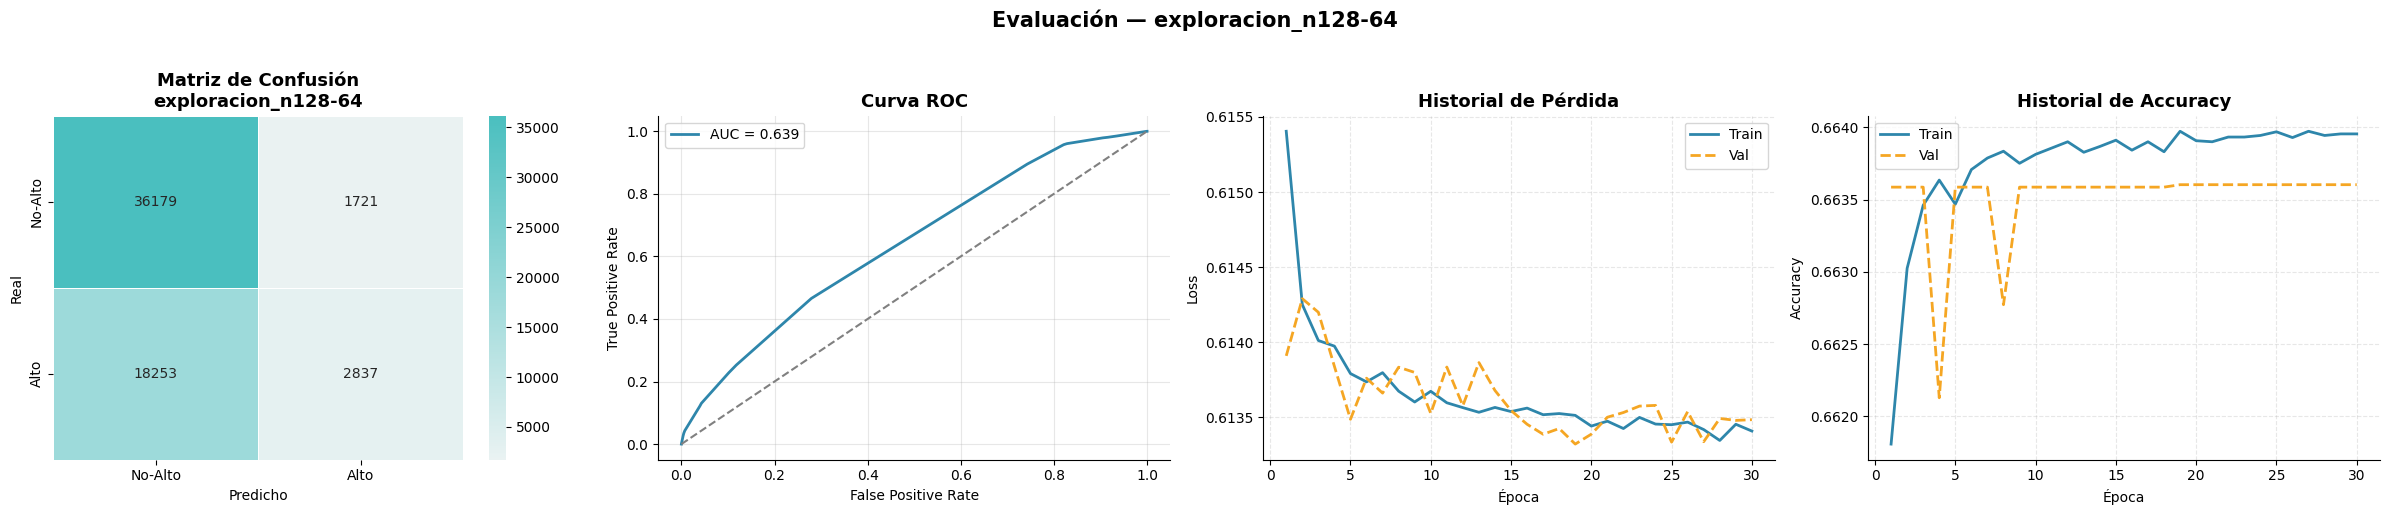

exploracion_n128-64       → F1: 0.2212 | AUC: 0.6388
🏃 View run exploracion_n128-64 at: http://localhost:5000/#/experiments/1/runs/8bb5c77ac1e94d039e9f2827a09be970
🧪 View experiment at: http://localhost:5000/#/experiments/1
              precision    recall  f1-score   support

     No-Alto       0.66      0.95      0.78     37900
        Alto       0.62      0.13      0.22     21090

    accuracy                           0.66     58990
   macro avg       0.64      0.54      0.50     58990
weighted avg       0.65      0.66      0.58     58990


 Modelo: exploracion_n256-128
  Accuracy       : 0.6614
  F1 Macro       : 0.5024
  Precision Macro: 0.6435
  Recall Macro   : 0.5446
  F1 No-Alto     : 0.7837
  F1 Alto        : 0.2212

              precision    recall  f1-score   support

     No-Alto       0.66      0.95      0.78     37900
        Alto       0.62      0.13      0.22     21090

    accuracy                           0.66     58990
   macro avg       0.64      0.54      0.50

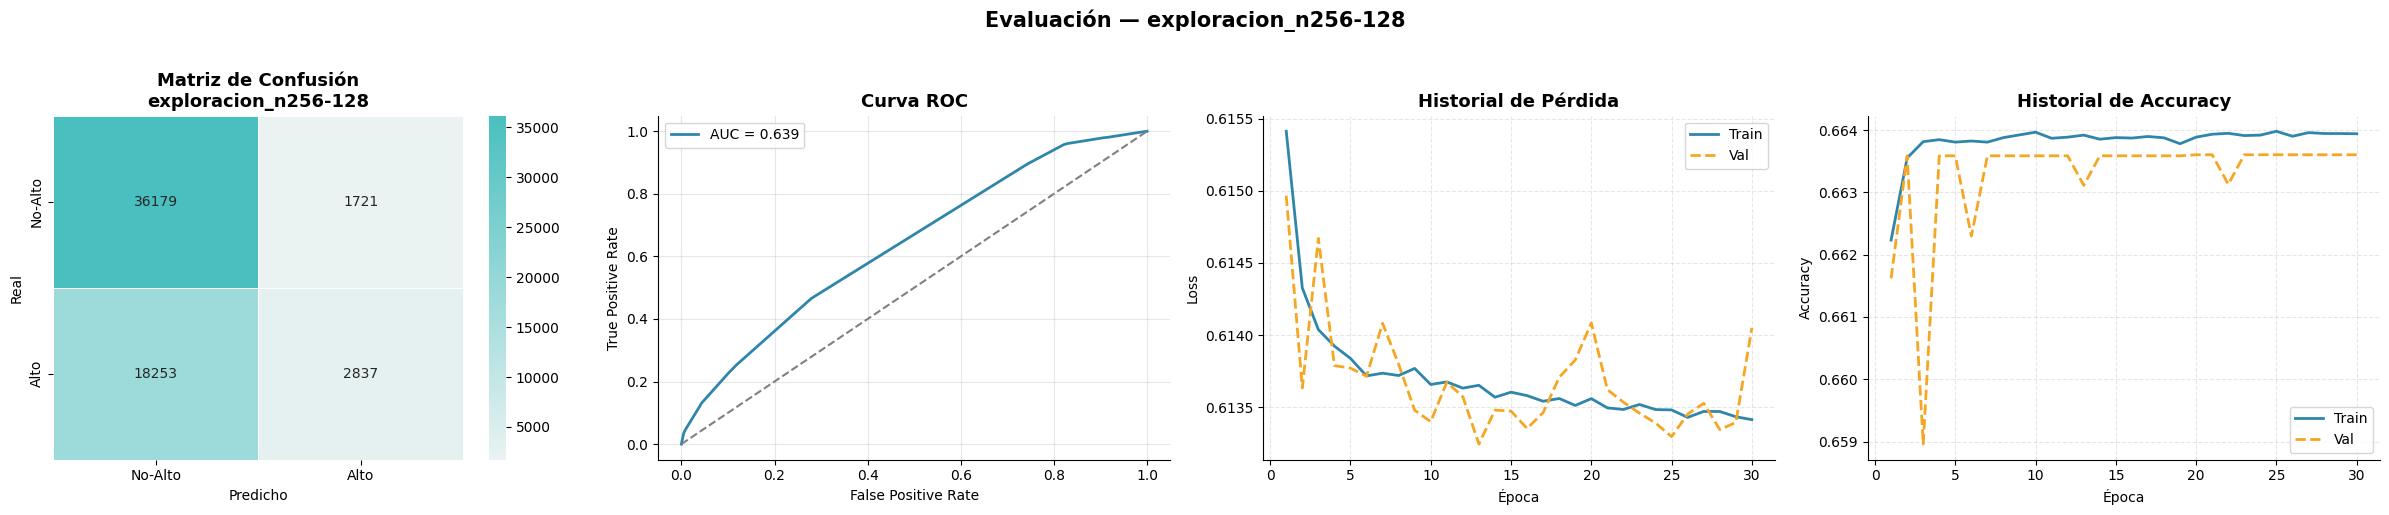

exploracion_n256-128      → F1: 0.2212 | AUC: 0.6389
🏃 View run exploracion_n256-128 at: http://localhost:5000/#/experiments/1/runs/5847e1904f1049788faef90e66e8b302
🧪 View experiment at: http://localhost:5000/#/experiments/1

 RESUMEN EXPLORACIÓN DE NEURONAS
Configuración     F1    AUC  Accuracy
        32-16 0.2213 0.6388    0.6614
        64-32 0.2160 0.6388    0.6615
       128-64 0.2212 0.6388    0.6614
      256-128 0.2212 0.6389    0.6614

→ Mejor configuración: 32-16
   F1: 0.2213 | AUC: 0.6388


In [10]:
import mlflow
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score, roc_auc_score

mlflow.set_tracking_uri('http://localhost:5000')
mlflow.set_experiment("Proyecto2Anlitica_Modelo1Preg1")
mlflow.end_run()

configuraciones = [
    (32,  16),
    (64,  32),   #base
    (128, 64),
    (256, 128),
]

resultados_experimentos = []

for n1, n2 in configuraciones:

    nombre_run = f"exploracion_n{n1}-{n2}"

    with mlflow.start_run(run_name=nombre_run):

        #modelo
        modelo_exp = Sequential([
            Input(shape=(N_FEATURES,)),
            Dense(n1, activation='relu'),
            Dense(n2, activation='relu'),
            Dense(1, activation='sigmoid')
        ])

        modelo_exp.compile(
            optimizer='adam',
            loss='binary_crossentropy',
            metrics=['accuracy']
        )

        #parametros
        params_exp = {
            'neuronas_c1': n1,
            'neuronas_c2': n2,
            'capas_ocultas': 2,
            'activacion': 'relu',
            'salida': 'sigmoid',
            'loss': 'binary_crossentropy',
            'optimizador': 'adam',
            'epochs': 30,
            'batch_size': 256,
            'tipo': 'exploracion_neuronas'
        }

        mlflow.log_params(params_exp)

        #entrenamiento
        hist_exp = modelo_exp.fit(
            X_train_scaled, y_train,
            epochs=30,
            batch_size=256,
            validation_data=(X_val_scaled, y_val),
            verbose=0
        )

        #predicciones
        y_prob_exp = modelo_exp.predict(X_test_scaled, verbose=0).ravel()
        y_pred_exp = (y_prob_exp >= 0.5).astype(int)

        #metricas completas
        acc_exp  = accuracy_score(y_test, y_pred_exp)
        f1_exp   = f1_score(y_test, y_pred_exp)
        prec_exp = precision_score(y_test, y_pred_exp)
        rec_exp  = recall_score(y_test, y_pred_exp)
        auc_exp  = roc_auc_score(y_test, y_prob_exp)

        #mlflow 
        mlflow.log_metrics({
            'accuracy': round(acc_exp, 4),
            'f1': round(f1_exp, 4),
            'precision': round(prec_exp, 4),
            'recall': round(rec_exp, 4),
            'roc_auc': round(auc_exp, 4)
        })

        #evaluacion visual
        metricas_exp = evaluar_modelo(
            nombre_run,
            y_test,
            y_pred_exp,
            y_prob=y_prob_exp,
            history=hist_exp,
            guardar=True
        )

        #guardar resutados
        resultados_experimentos.append({
            'Configuración': f'{n1}-{n2}',
            'F1': round(f1_exp, 4),
            'AUC': round(auc_exp, 4),
            'Accuracy': round(acc_exp, 4)
        })

        print(f"{nombre_run:25s} → F1: {f1_exp:.4f} | AUC: {auc_exp:.4f}")

#resumen 
df_exp = pd.DataFrame(resultados_experimentos)

print("\n" + "="*55)
print(" RESUMEN EXPLORACIÓN DE NEURONAS")
print("="*55)
print(df_exp.to_string(index=False))

#mejor modelo...segun f1
mejor = df_exp.loc[df_exp['F1'].idxmax()]

print(f"\n→ Mejor configuración: {mejor['Configuración']}")
print(f"   F1: {mejor['F1']:.4f} | AUC: {mejor['AUC']:.4f}")

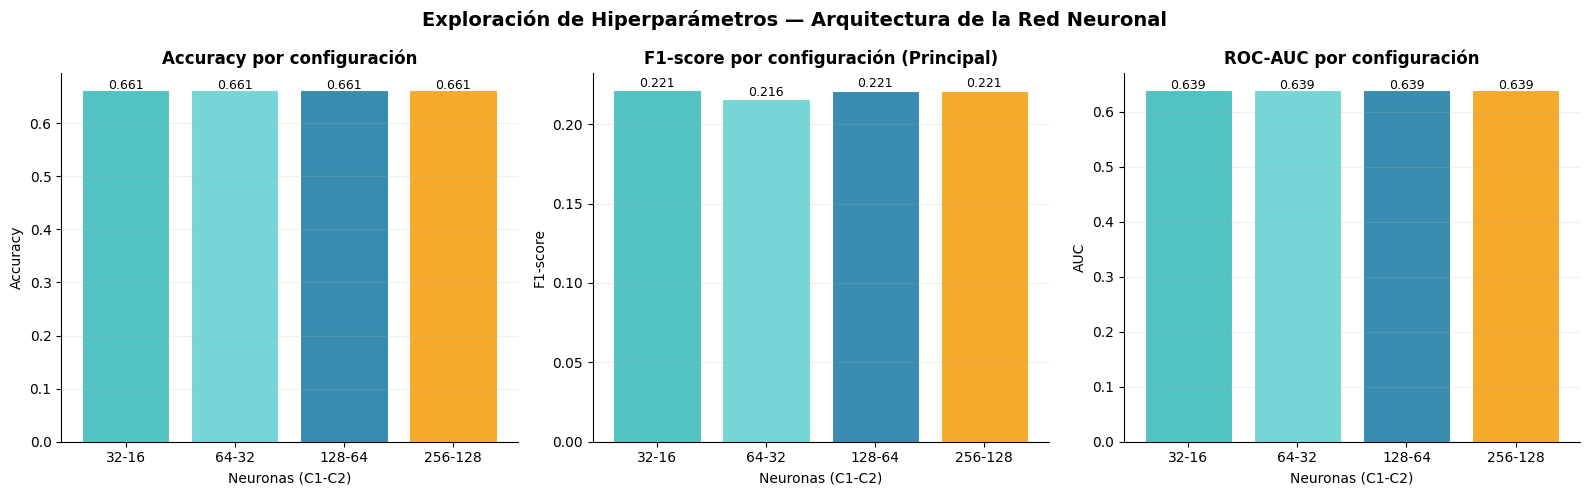

In [11]:
#colores de la pp
COLOR_BAJO = '#F5A623'
COLOR_ALTO = '#2E86AB'
COLOR_MAIN = '#4ABFBF'
COLOR_LIGHT = '#6FD4D4'

palette = [COLOR_MAIN, COLOR_LIGHT, COLOR_ALTO, COLOR_BAJO]

fig, axes = plt.subplots(1, 3, figsize=(16, 5), facecolor='white')

#accuracy
axes[0].bar(
    df_exp['Configuración'],
    df_exp['Accuracy'],
    color=palette,
    edgecolor='white',
    linewidth=0.8,
    alpha=0.95
)

axes[0].set_title('Accuracy por configuración', fontweight='bold')
axes[0].set_xlabel('Neuronas (C1-C2)')
axes[0].set_ylabel('Accuracy')

axes[0].grid(axis='y', alpha=0.2)
axes[0].spines[['top', 'right']].set_visible(False)

for i, v in enumerate(df_exp['Accuracy']):
    axes[0].text(i, v + 0.002, f'{v:.3f}', ha='center', fontsize=9)


#F1 metricas más imp
axes[1].bar(
    df_exp['Configuración'],
    df_exp['F1'],
    color=palette,
    edgecolor='white',
    linewidth=0.8,
    alpha=0.95
)

axes[1].set_title('F1-score por configuración (Principal)', fontweight='bold')
axes[1].set_xlabel('Neuronas (C1-C2)')
axes[1].set_ylabel('F1-score')

axes[1].grid(axis='y', alpha=0.2)
axes[1].spines[['top', 'right']].set_visible(False)

for i, v in enumerate(df_exp['F1']):
    axes[1].text(i, v + 0.002, f'{v:.3f}', ha='center', fontsize=9)


#AUC
axes[2].bar(
    df_exp['Configuración'],
    df_exp['AUC'],
    color=palette,
    edgecolor='white',
    linewidth=0.8,
    alpha=0.95
)

axes[2].set_title('ROC-AUC por configuración', fontweight='bold')
axes[2].set_xlabel('Neuronas (C1-C2)')
axes[2].set_ylabel('AUC')

axes[2].grid(axis='y', alpha=0.2)
axes[2].spines[['top', 'right']].set_visible(False)

for i, v in enumerate(df_exp['AUC']):
    axes[2].text(i, v + 0.002, f'{v:.3f}', ha='center', fontsize=9)


#Etiquetas
plt.suptitle(
    'Exploración de Hiperparámetros — Arquitectura de la Red Neuronal',
    fontsize=14,
    fontweight='bold'
)

plt.tight_layout()
plt.show()


## Modelos!!

In [12]:
mlflow.end_run()

## Modelo 1 + Mlflow

── Summary MLP Base ──


Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_12 (Dense)                │ (None, 64)             │         1,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_13 (Dense)                │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_14 (Dense)                │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,137 (12.25 KB)

 Trainable params: 3,137 (12.25 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/50
1076/1076 ━━━━━━━━━━━━━━━━━━━━ 9s 6ms/step - accuracy: 0.6608 - loss: 0.6172 - val_accuracy: 0.6636 - val_loss: 0.6150
Epoch 2/50
1076/1076 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.6634 - loss: 0.6140 - val_accuracy: 0.6636 - val_loss: 0.6137
Epoch 3/50
1076/1076 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.6632 - loss: 0.6139 - val_accuracy: 0.6623 - val_loss: 0.6141
Epoch 4/50
1076/1076 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.6636 - loss: 0.6139 - val_accuracy: 0.6636 - val_loss: 0.6140
Epoch 5/50
1076/1076 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.6637 - loss: 0.6138 - val_accuracy: 0.6631 - val_loss: 0.6136
Epoch 6/50
1076/1076 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.6635 - loss: 0.6137 - val_accuracy: 0.6631 - val_loss: 0.6139
Epoch 7/50
1076/1076 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - accuracy: 0.6637 - loss: 0.6138 - val_accuracy: 0.6636 - val_loss: 0.6137
Epoch 8/50
1076/1076 ━━━━━━━━━━━━━━━━━━━━ 6s 5ms/step - accuracy: 0.6638 - loss: 0.6137 - 

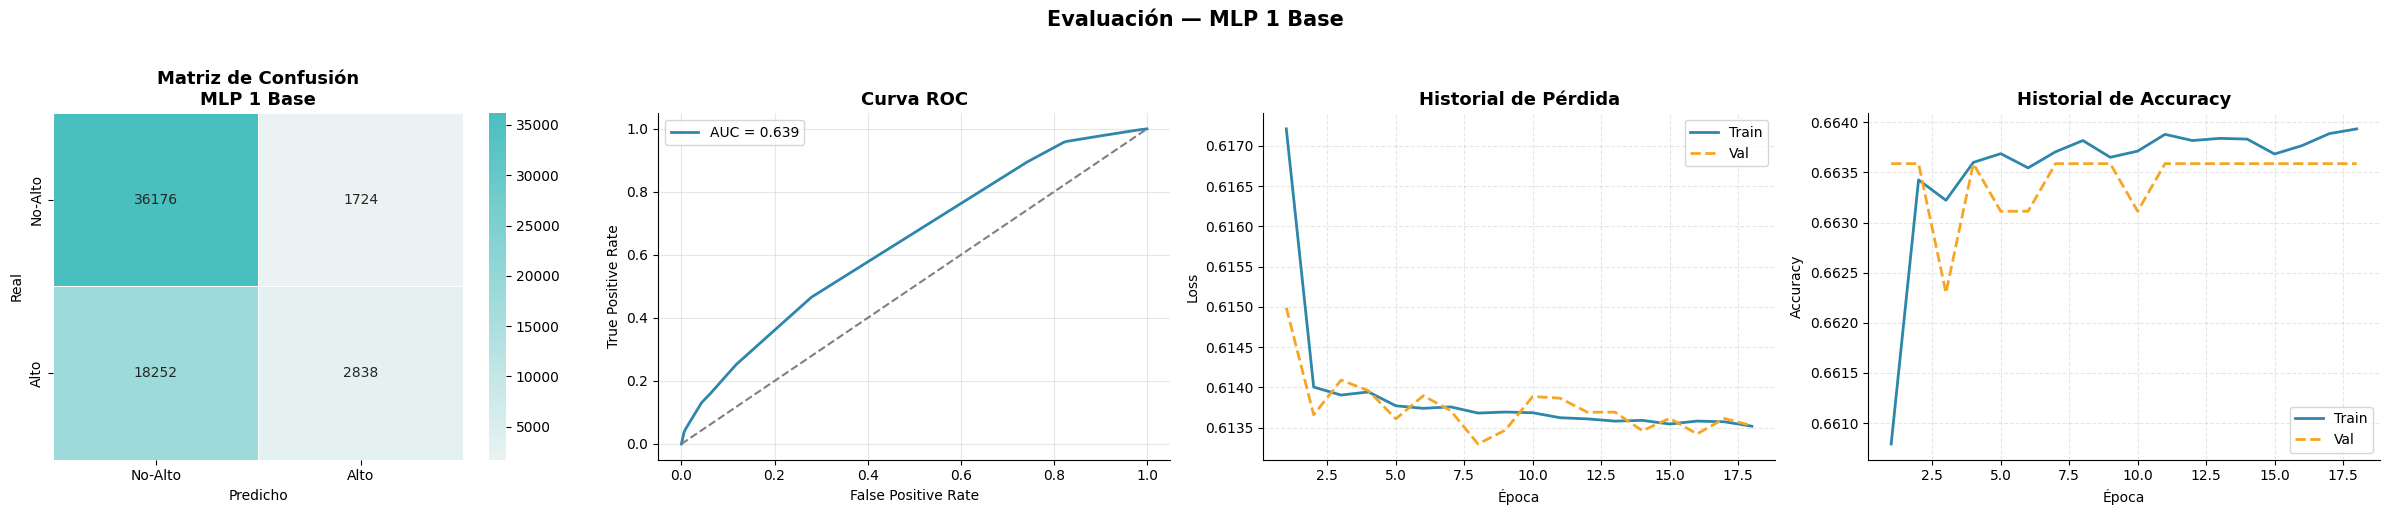

2026/05/24 15:56:27 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/05/24 15:56:28 WARNING mlflow.tensorflow: You are saving a TensorFlow Core model or Keras model without a signature. Inference with mlflow.pyfunc.spark_udf() will not work unless the model's pyfunc representation accepts pandas DataFrames as inference inputs.


MLP 1 Base registrado en MLflow
🏃 View run MLP_1_Base at: http://localhost:5000/#/experiments/1/runs/e16ce40f1ede4457b3b6028b58f8739c
🧪 View experiment at: http://localhost:5000/#/experiments/1


In [13]:
import mlflow
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.optimizers import Adam
import pandas as pd
import numpy as np

mlflow.set_tracking_uri('http://localhost:5000')
mlflow.set_experiment("Proyecto2Anlitica_Modelo1Preg1")

N_FEATURES = X_train_scaled.shape[1]

with mlflow.start_run(run_name="MLP_1_Base"):

    #modelo
    model_base = Sequential([
        Input(shape=(N_FEATURES,)),
        Dense(64, activation='relu'),
        Dense(32, activation='relu'),
        Dense(1, activation='sigmoid')
    ])

    optimizer = Adam(learning_rate=0.0005)

    model_base.compile(
        optimizer=optimizer,
        loss='binary_crossentropy',
        metrics=['accuracy']
    )

    print("── Summary MLP Base ──")
    model_base.summary()

    #parametros
    params = {
        'arquitectura': f'{N_FEATURES}-64-32-1',
        'capas_ocultas': 2,
        'neuronas': '64-32',
        'activacion_salida': 'sigmoid',
        'loss': 'binary_crossentropy',
        'target': 'Alto_vs_NoAlto',
        'learning_rate': 0.0005,
        'epochs_max': 50,
        'batch_size': 256,
        'total_params': model_base.count_params()
    }

    mlflow.log_params(params)

    #parar
    es = EarlyStopping(
        patience=10,
        restore_best_weights=True,
        monitor='val_loss'
    )

    #entrenamiento
    history_base = model_base.fit(
        X_train_scaled, y_train,
        epochs=50,
        batch_size=256,
        validation_data=(X_val_scaled, y_val),
        callbacks=[es],
        verbose=1
    )

    mlflow.log_param('epochs_efectivos', len(history_base.history['loss']))

    #predicciones
    y_prob_base = model_base.predict(X_test_scaled, verbose=0).ravel()
    y_pred_base = (y_prob_base >= 0.5).astype(int)

    #evalaucion c
    metricas_base = evaluar_modelo(
        "MLP 1 Base",
        y_test,
        y_pred_base,
        y_prob=y_prob_base,  
        history=history_base
    )

    #metricas finales
    metricas_limpias = {
        k: float(v)
        for k, v in metricas_base.items()
        if isinstance(v, (int, float, np.floating))
    }

    mlflow.log_metrics(metricas_limpias)

    #guardar metricas
    mlflow.log_dict(metricas_base, "metricas_completas.json")

    # ── guardar history ─────────────────────────
    hist_df = pd.DataFrame(history_base.history)
    hist_df.to_csv("history_base.csv", index=False)
    mlflow.log_artifact("history_base.csv")

    #guardar modelo
    mlflow.tensorflow.log_model(model_base, "model")

    model_base.save('modelo1.keras')

    print("MLP 1 Base registrado en MLflow")

## Modelo 2 + mlflow

── Summary MLP Optimizada ──


Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_15 (Dense)                │ (None, 64)             │         1,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_16 (Dense)                │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 32)             │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_17 (Dense)                │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,521 (13.75 KB)

 Trainable params: 3,329 (13.00 KB)

 Non-trainable params: 192 (768.00 B)

Epoch 1/100
1076/1076 ━━━━━━━━━━━━━━━━━━━━ 15s 9ms/step - accuracy: 0.6386 - loss: 0.6508 - val_accuracy: 0.6636 - val_loss: 0.6143
Epoch 2/100
1076/1076 ━━━━━━━━━━━━━━━━━━━━ 9s 8ms/step - accuracy: 0.6582 - loss: 0.6222 - val_accuracy: 0.6636 - val_loss: 0.6139
Epoch 3/100
1076/1076 ━━━━━━━━━━━━━━━━━━━━ 10s 8ms/step - accuracy: 0.6611 - loss: 0.6179 - val_accuracy: 0.6631 - val_loss: 0.6136
Epoch 4/100
1076/1076 ━━━━━━━━━━━━━━━━━━━━ 8s 8ms/step - accuracy: 0.6616 - loss: 0.6166 - val_accuracy: 0.6631 - val_loss: 0.6138
Epoch 5/100
1076/1076 ━━━━━━━━━━━━━━━━━━━━ 8s 8ms/step - accuracy: 0.6623 - loss: 0.6158 - val_accuracy: 0.6631 - val_loss: 0.6136
Epoch 6/100
1076/1076 ━━━━━━━━━━━━━━━━━━━━ 8s 8ms/step - accuracy: 0.6628 - loss: 0.6157 - val_accuracy: 0.6636 - val_loss: 0.6137
Epoch 7/100
1076/1076 ━━━━━━━━━━━━━━━━━━━━ 8s 8ms/step - accuracy: 0.6627 - loss: 0.6155 - val_accuracy: 0.6636 - val_loss: 0.6136
Epoch 8/100
1076/1076 ━━━━━━━━━━━━━━━━━━━━ 8s 8ms/step - accuracy: 0.6631 - loss:

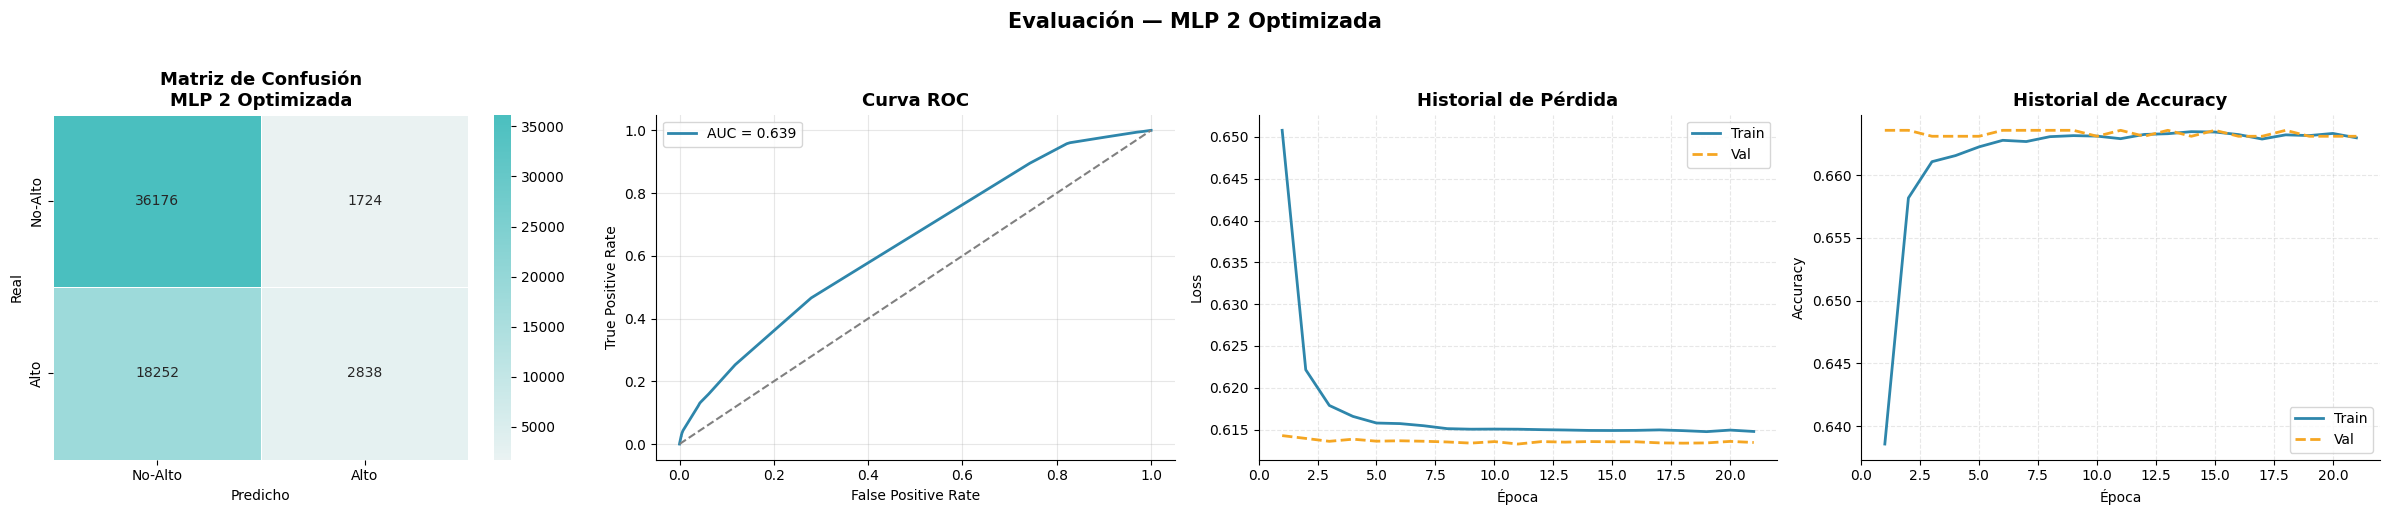

2026/05/24 16:00:11 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/05/24 16:00:12 WARNING mlflow.tensorflow: You are saving a TensorFlow Core model or Keras model without a signature. Inference with mlflow.pyfunc.spark_udf() will not work unless the model's pyfunc representation accepts pandas DataFrames as inference inputs.


MLP 2 Optimizada registrada en MLflow
🏃 View run MLP_2_Optimizada at: http://localhost:5000/#/experiments/1/runs/11a7647e4ee94aba8b1f9ee56b396116
🧪 View experiment at: http://localhost:5000/#/experiments/1


In [14]:
import mlflow
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Input, Dropout, BatchNormalization
import pandas as pd
import numpy as np
import os

mlflow.set_tracking_uri('http://localhost:5000')
mlflow.set_experiment("Proyecto2Anlitica_Modelo1Preg1")
mlflow.end_run()

N_FEATURES = X_train_scaled.shape[1]

with mlflow.start_run(run_name="MLP_2_Optimizada"):

    # ── modelo ─────────────────────────
    model_opt = Sequential([
        Input(shape=(N_FEATURES,)),
        Dense(64, activation='relu'),
        BatchNormalization(),
        Dropout(0.3),

        Dense(32, activation='relu'),
        BatchNormalization(),
        Dropout(0.2),

        Dense(1, activation='sigmoid')
    ])

    optimizer = Adam(learning_rate=0.0005)

    model_opt.compile(
        optimizer=optimizer,
        loss='binary_crossentropy',
        metrics=['accuracy']
    )

    print("── Summary MLP Optimizada ──")
    model_opt.summary()

    #parametros
    params = {
        'arquitectura': f'{N_FEATURES}-64-32-1',
        'capas_ocultas': 2,
        'neuronas': '64-32',
        'activacion_ocultas': 'relu',
        'activacion_salida': 'sigmoid',
        'loss': 'binary_crossentropy',
        'target': 'Alto_vs_NoAlto',
        'dropout': '0.3-0.2',
        'batch_norm': True,
        'learning_rate': 0.0005,
        'epochs_max': 100,
        'batch_size': 256,
        'early_stopping_patience': 10,
        'total_params': model_opt.count_params()
    }

    mlflow.log_params(params)

    #parar
    es = EarlyStopping(
        patience=10,
        restore_best_weights=True,
        monitor='val_loss'
    )

    #entrenar
    history_opt = model_opt.fit(
        X_train_scaled, y_train,
        epochs=100,
        batch_size=256,
        validation_data=(X_val_scaled, y_val),
        callbacks=[es],
        verbose=1
    )

    mlflow.log_param('epochs_efectivos', len(history_opt.history['loss']))

    #predecir
    y_prob_opt = model_opt.predict(X_test_scaled, verbose=0).ravel()
    y_pred_opt = (y_prob_opt >= 0.5).astype(int)

    #evaluar
    metricas_opt = evaluar_modelo(
        "MLP 2 Optimizada",
        y_test,
        y_pred_opt,
        y_prob=y_prob_opt,   # 🔥 IMPORTANTE
        history=history_opt
    )

    #metricas limpias
    metricas_limpias = {
        k: float(v)
        for k, v in metricas_opt.items()
        if isinstance(v, (int, float, np.floating))
    }

    mlflow.log_metrics(metricas_limpias)

    #guardar metricas
    mlflow.log_dict(metricas_opt, "metricas_completas.json")

    #hustory
    hist_df = pd.DataFrame(history_opt.history)
    hist_df.to_csv("history_opt.csv", index=False)
    mlflow.log_artifact("history_opt.csv")

    #guardar gráfica
    if os.path.exists('grafica_MLP_2_Optimizada.png'):
        mlflow.log_artifact('grafica_MLP_2_Optimizada.png')

    #guardar
    mlflow.tensorflow.log_model(model_opt, "model")
    model_opt.save('modelo_mlp_opt.keras')

    print("MLP 2 Optimizada registrada en MLflow")

## Comparación y metricas finales

In [15]:
#tabla

tabla_final = pd.DataFrame([
    {'Modelo': 'MLP Base',       **metricas_base},
    {'Modelo': 'MLP Optimizada', **metricas_opt},
]).set_index('Modelo')

print("\n" + "="*60)
print(" COMPARACIÓN FINAL DE MODELOS")
print("="*60)
print(tabla_final.to_string())

#verificar métricas clave
for col in ['f1_alto', 'roc_auc']:
    if col not in tabla_final.columns:
        raise ValueError(f"La métrica '{col}' no está en metricas_base/metricas_opt")

#seleccionar mejor modelo
# prioridad: F1 de la clase "Alto"
mejor = tabla_final['f1_alto'].astype(float).idxmax()

print(
    f"\n→ Modelo seleccionado: {mejor} "
    f"(F1 Alto = {tabla_final.loc[mejor, 'f1_alto']:.4f})"
)

#más info
print(
    f"AUC: {tabla_final.loc[mejor, 'roc_auc']:.4f} | "
    f"Precision: {tabla_final.loc[mejor, 'precision']:.4f} | "
    f"Recall: {tabla_final.loc[mejor, 'recall']:.4f}"
)


 COMPARACIÓN FINAL DE MODELOS
                accuracy  f1_macro  precision  recall  f1_no_alto  f1_alto  roc_auc
Modelo                                                                             
MLP Base          0.6614    0.5025     0.6434  0.5445      0.7836   0.2213   0.6388
MLP Optimizada    0.6614    0.5025     0.6434  0.5445      0.7836   0.2213   0.6388

→ Modelo seleccionado: MLP Base (F1 Alto = 0.2213)
AUC: 0.6388 | Precision: 0.6434 | Recall: 0.5445


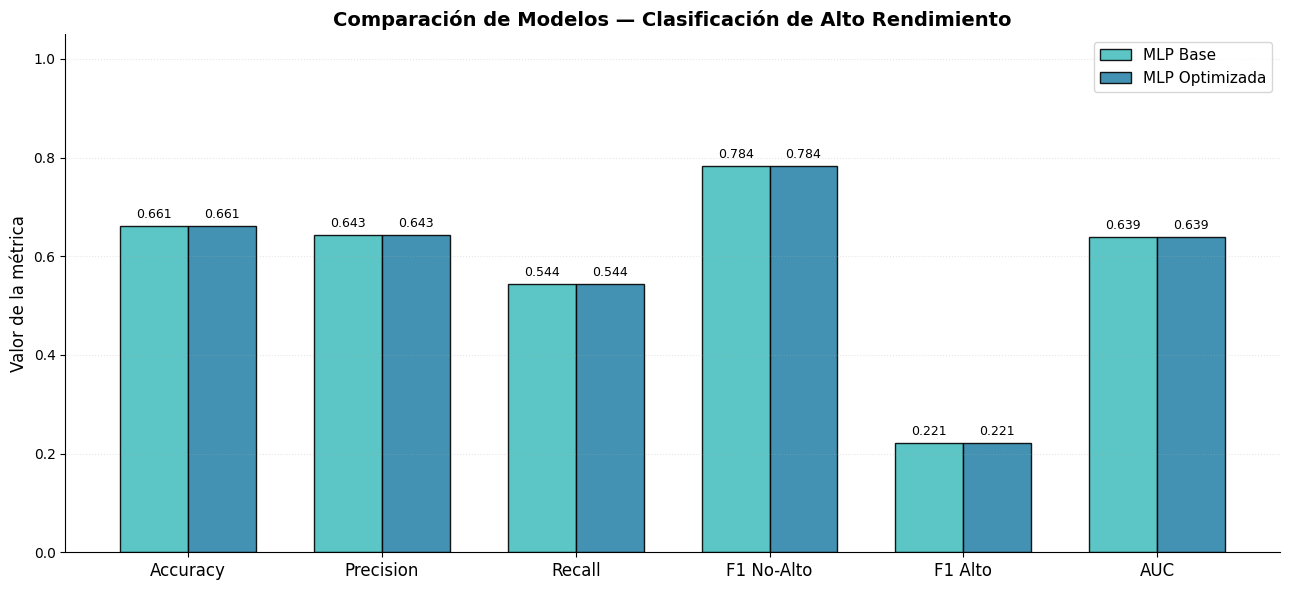

In [16]:
#metricas finales
metricas_nombres = [
    'accuracy',
    'precision',
    'recall',
    'f1_no_alto',
    'f1_alto',
    'roc_auc'
]

etiquetas = [
    'Accuracy',
    'Precision',
    'Recall',
    'F1 No-Alto',
    'F1 Alto',
    'AUC'
]

x = np.arange(len(etiquetas))
width = 0.35

#colores de la pp
COLOR_BASE = '#4ABFBF'   
COLOR_OPT  = '#2E86AB'   
COLOR_EDGE = 'black'

fig, ax = plt.subplots(figsize=(13, 6), facecolor='white')
ax.set_facecolor('white')

#valores
vals_base = [metricas_base.get(m, 0) for m in metricas_nombres]
vals_opt  = [metricas_opt.get(m, 0)  for m in metricas_nombres]

#barras
bars1 = ax.bar(
    x - width/2, vals_base, width,
    label='MLP Base',
    color=COLOR_BASE,
    edgecolor=COLOR_EDGE,
    alpha=0.9
)

bars2 = ax.bar(
    x + width/2, vals_opt, width,
    label='MLP Optimizada',
    color=COLOR_OPT,
    edgecolor=COLOR_EDGE,
    alpha=0.9
)

#ejes
ax.set_xticks(x)
ax.set_xticklabels(etiquetas, fontsize=12)
ax.set_ylabel('Valor de la métrica', fontsize=12)

ax.set_title(
    'Comparación de Modelos — Clasificación de Alto Rendimiento',
    fontsize=14,
    fontweight='bold'
)

#estilo
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.grid(axis='y', linestyle=':', alpha=0.3)

ax.set_ylim(0, 1.05)
ax.legend(fontsize=11)

#etiquetas
for bars in [bars1, bars2]:
    for bar in bars:
        height = bar.get_height()
        ax.text(
            bar.get_x() + bar.get_width()/2,
            height + 0.01,
            f'{height:.3f}',
            ha='center',
            va='bottom',
            fontsize=9
        )

plt.tight_layout()
plt.show()

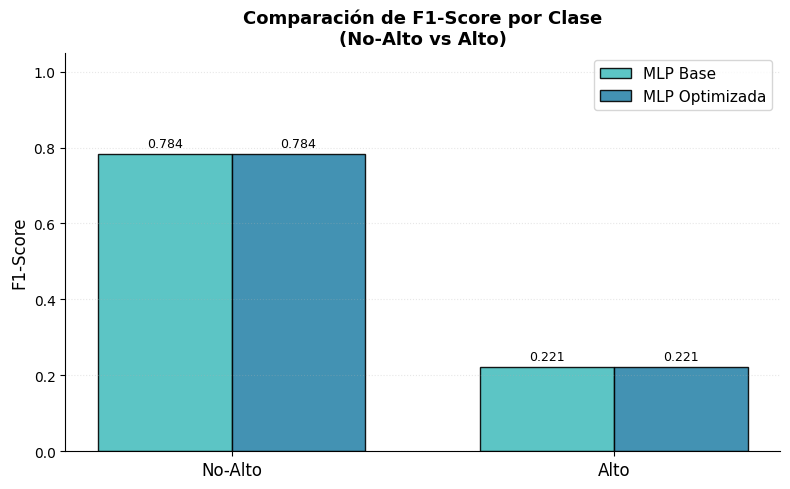

In [17]:
# gráfica por clase
fig, ax = plt.subplots(figsize=(8, 5), facecolor='white')
ax.set_facecolor('white')

#clases
clases_plot = ['No-Alto', 'Alto']

# valores
f1_base_clases = [
    metricas_base.get('f1_no_alto', 0),
    metricas_base.get('f1_alto', 0)
]

f1_opt_clases = [
    metricas_opt.get('f1_no_alto', 0),
    metricas_opt.get('f1_alto', 0)
]

x2 = np.arange(len(clases_plot))
width = 0.35
#colores de la pp
COLOR_BASE = '#4ABFBF'   
COLOR_OPT  = '#2E86AB'  

#barras
bars1 = ax.bar(
    x2 - width/2, f1_base_clases, width,
    label='MLP Base',
    color=COLOR_BASE,
    edgecolor='black',
    alpha=0.9
)

bars2 = ax.bar(
    x2 + width/2, f1_opt_clases, width,
    label='MLP Optimizada',
    color=COLOR_OPT,
    edgecolor='black',
    alpha=0.9
)

#ejes
ax.set_xticks(x2)
ax.set_xticklabels(clases_plot, fontsize=12)

ax.set_ylabel('F1-Score', fontsize=12)

ax.set_title(
    'Comparación de F1-Score por Clase\n(No-Alto vs Alto)',
    fontsize=13,
    fontweight='bold'
)

#estilo
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.grid(axis='y', linestyle=':', alpha=0.3)

ax.legend(fontsize=11)
ax.set_ylim(0, 1.05)

#etiquetas
for bars in [bars1, bars2]:
    for bar in bars:
        height = bar.get_height()
        ax.text(
            bar.get_x() + bar.get_width()/2,
            height + 0.01,
            f'{height:.3f}',
            ha='center',
            va='bottom',
            fontsize=9
        )

plt.tight_layout()
plt.show()